# 01 — Baseline Model (FP32)
This notebook trains a standard ResNet-18 on CIFAR-10 using full 32-bit precision.
This is our reference model that we will compare against Mixed Precision and QAT.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import time
import os
import matplotlib.pyplot as plt

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda


In [3]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),     # Data augmentation
    transforms.RandomCrop(32, padding=4),  # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False, num_workers=2
)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

Training samples : 50000
Test samples     : 10000


In [4]:
model = resnet18(pretrained=False)

# CIFAR-10 images are 32x32 (much smaller than ImageNet)
# So we replace the first conv layer to suit smaller images
model.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                        stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()  # Remove maxpool for small images

# CIFAR-10 has 10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)
print(model)

d:\quantization_project\edge-ai\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\quantization_project\edge-ai\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [5]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, accuracy

In [6]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, accuracy

In [7]:
NUM_EPOCHS = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("Starting baseline training...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_loss, test_acc   = evaluate(model, test_loader, criterion)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

total_time = time.time() - start_time
print(f"\nTotal training time: {total_time/60:.2f} minutes")

Starting baseline training...

Epoch [01/10] Train Loss: 2.0823 | Train Acc: 25.45% | Test Loss: 1.7347 | Test Acc: 34.45%
Epoch [02/10] Train Loss: 1.5641 | Train Acc: 42.23% | Test Loss: 1.4294 | Test Acc: 47.41%
Epoch [03/10] Train Loss: 1.2646 | Train Acc: 54.05% | Test Loss: 1.2702 | Test Acc: 53.99%
Epoch [04/10] Train Loss: 1.0083 | Train Acc: 63.95% | Test Loss: 1.0859 | Test Acc: 62.28%
Epoch [05/10] Train Loss: 0.8051 | Train Acc: 71.48% | Test Loss: 0.8095 | Test Acc: 71.75%
Epoch [06/10] Train Loss: 0.6519 | Train Acc: 77.05% | Test Loss: 0.7272 | Test Acc: 75.36%
Epoch [07/10] Train Loss: 0.5413 | Train Acc: 81.19% | Test Loss: 0.5928 | Test Acc: 79.91%
Epoch [08/10] Train Loss: 0.4518 | Train Acc: 84.39% | Test Loss: 0.4906 | Test Acc: 82.95%
Epoch [09/10] Train Loss: 0.3716 | Train Acc: 87.21% | Test Loss: 0.4304 | Test Acc: 85.19%
Epoch [10/10] Train Loss: 0.3234 | Train Acc: 88.86% | Test Loss: 0.3967 | Test Acc: 86.23%

Total training time: 9.31 minutes


In [8]:
os.makedirs("saved_models", exist_ok=True)
torch.save(model.state_dict(), "saved_models/baseline.pth")
print("Model saved to saved_models/baseline.pth")

# Save metrics for use in evaluation notebook
import json
metrics = {
    "train_losses" : train_losses,
    "test_losses"  : test_losses,
    "train_accs"   : train_accs,
    "test_accs"    : test_accs,
    "total_time"   : total_time,
    "final_test_acc": test_accs[-1]
}
os.makedirs("metrics", exist_ok=True)
with open("metrics/baseline_metrics.json", "w") as f:
    json.dump(metrics, f)
print("Metrics saved to metrics/baseline_metrics.json")

Model saved to saved_models/baseline.pth
Metrics saved to metrics/baseline_metrics.json


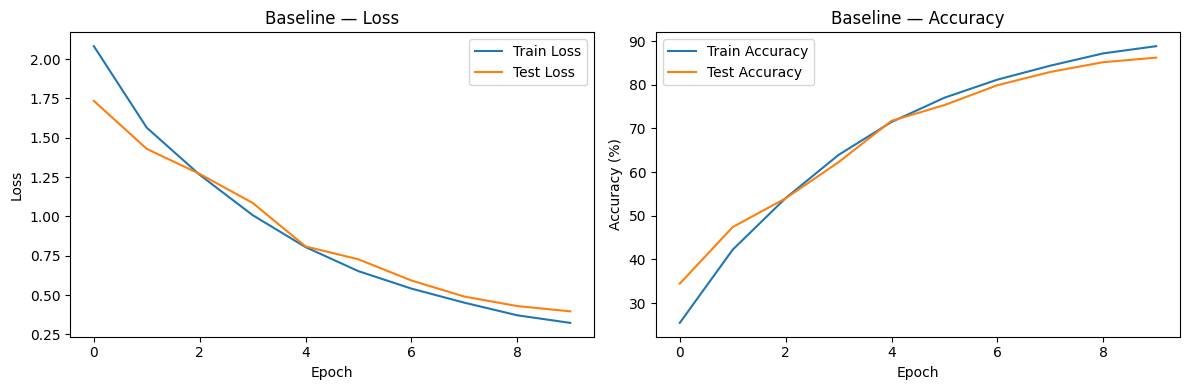

Final Test Accuracy: 86.23%


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(test_losses,  label="Test Loss")
ax1.set_title("Baseline — Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(train_accs, label="Train Accuracy")
ax2.plot(test_accs,  label="Test Accuracy")
ax2.set_title("Baseline — Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()

plt.tight_layout()
plt.savefig("metrics/baseline_curves.png")
plt.show()
print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")